# Análisis exploratorio de BD Dengue

In [59]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [60]:
# Cargar BD
df = pd.read_excel(r"C:\Users\usuario1\OneDrive - Universidad de Antioquia\UNIVERSIDAD DE ANTIOQUIA\Proyecto SAT Dengue\Bases de datos\Secretaria de salud\BD_DENGUE_2021-2025_PROCE_CAUCASIA.xlsx")
df.head()

,fec_not,semana,año,area_,localidad_,cen_pobla_,vereda_,bar_ver_,dir_res_,ndep_proce,nmun_proce,nmun_resi
0,2021-02-16,3,2021,2,NaN,CAUCASIA,NaN,CAUCASIA,CR 39 E 48 C SUR 36,ANTIOQUIA,CAUCASIA,ENVIGADO
1,2021-02-19,6,2021,2,NaN,CAUCASIA,NaN,CAUCASIA,CL 29 A 42-99,ANTIOQUIA,CAUCASIA,BOGOTA
2,2021-02-28,7,2021,1,VILLA GRANDA,NaN,NaN,VILLA GRANDA,VILLA GRANDA,ANTIOQUIA,CAUCASIA,CAUCASIA
3,2021-03-12,9,2021,3,NaN,NaN,CUTURÚ,CUTURÚ,CUTURU,ANTIOQUIA,CAUCASIA,CAUCASIA
4,2021-04-05,13,2021,1,LA YE,NaN,NaN,LA YE,LA Y CARRERA 22 33 19,ANTIOQUIA,CAUCASIA,CAUCASIA


In [61]:
# Ver estructura de la base de datos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6104 entries, 0 to 6103
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   fec_not     6104 non-null   datetime64[ns]
 1   semana      6104 non-null   int64         
 2   año         6104 non-null   int64         
 3   area_       6104 non-null   int64         
 4   localidad_  5131 non-null   object        
 5   cen_pobla_  59 non-null     object        
 6   vereda_     914 non-null    object        
 7   bar_ver_    6104 non-null   object        
 8   dir_res_    6104 non-null   object        
 9   ndep_proce  6104 non-null   object        
 10  nmun_proce  6104 non-null   object        
 11  nmun_resi   6104 non-null   object        
dtypes: datetime64[ns](1), int64(3), object(8)
memory usage: 572.4+ KB


In [62]:
# Revisar valores nulos
df.isnull().sum()

fec_not          0
semana           0
año              0
area_            0
localidad_     973
cen_pobla_    6045
vereda_       5190
bar_ver_         0
dir_res_         0
ndep_proce       0
nmun_proce       0
nmun_resi        0
dtype: int64

In [63]:
# Convertir la columna 'fec_not' a formato de fecha
df['fec_not'] = pd.to_datetime(df['fec_not'])

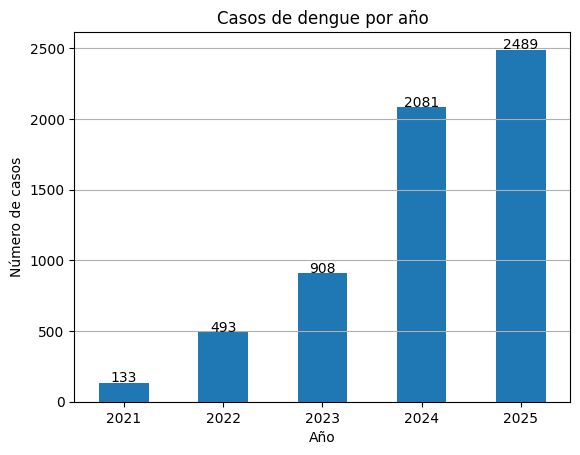

In [64]:
# Casos por año
casos_año = df['año'].value_counts().sort_index()

plt.figure()

ax = casos_año.plot(kind='bar')

plt.title("Casos de dengue por año")
plt.xlabel("Año")
plt.ylabel("Número de casos")
plt.xticks(rotation=0)
plt.grid(axis='y')

# Mostrar valores sobre cada barra
for i, v in enumerate(casos_año):
    ax.text(i, v + 5, str(v), ha='center')

plt.show()

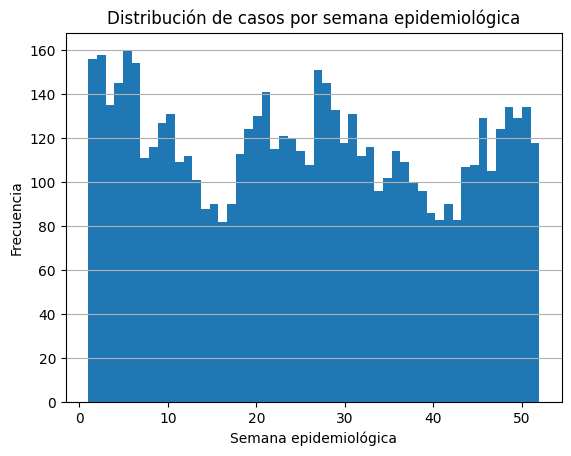

In [65]:
# Casos por semana epidemiológica
plt.figure()

plt.hist(df['semana'], bins=52)

plt.title("Distribución de casos por semana epidemiológica")
plt.xlabel("Semana epidemiológica")
plt.ylabel("Frecuencia")
plt.grid(axis='y')

plt.show()

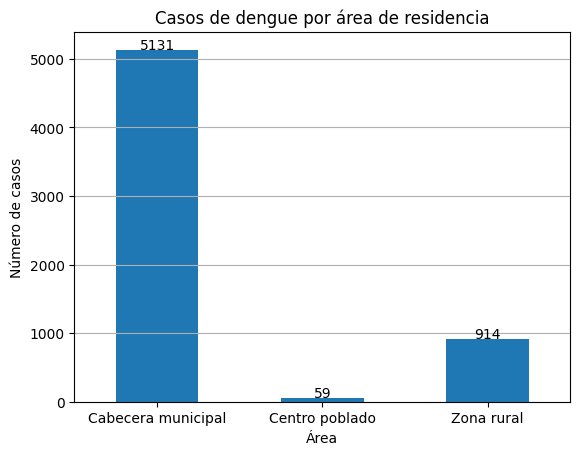

In [66]:
# Analizar casos por área
casos_area = df['area_'].value_counts().sort_index()

# Reemplazar códigos por nombres
casos_area.index = ['Cabecera municipal', 'Centro poblado', 'Zona rural']

plt.figure()

ax = casos_area.plot(kind='bar')

plt.title("Casos de dengue por área de residencia")
plt.xlabel("Área")
plt.ylabel("Número de casos")
plt.xticks(rotation=0)
plt.grid(axis='y')

# Mostrar número de casos sobre cada barra
for i, v in enumerate(casos_area):
    ax.text(i, v + 5, str(v), ha='center')

plt.show()

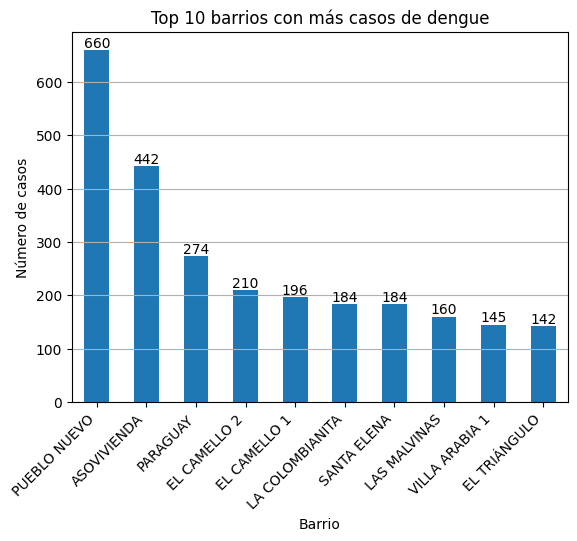

In [67]:
barrios = df['bar_ver_'].value_counts().head(10)

plt.figure()

barrios.plot(kind='bar')

plt.title("Top 10 barrios con más casos de dengue")
plt.xlabel("Barrio")
plt.ylabel("Número de casos")

plt.xticks(rotation=45, ha='right')
plt.grid(axis='y')

# Mostrar número de casos sobre cada barra
for i, v in enumerate(barrios):
    plt.text(i, v + 5, str(v), ha='center')

plt.show()

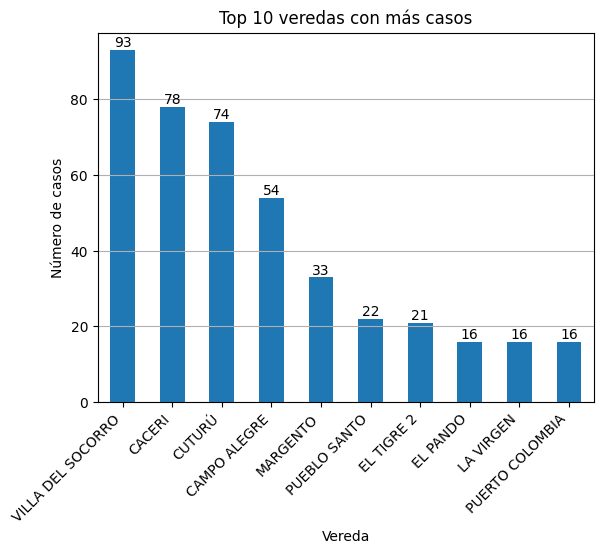

In [68]:
veredas = df['vereda_'].value_counts().head(10)

plt.figure()

veredas.plot(kind='bar')

plt.title("Top 10 veredas con más casos")
plt.xlabel("Vereda")
plt.ylabel("Número de casos")

plt.xticks(rotation=45, ha='right')
plt.grid(axis='y')

# Mostrar número de casos sobre cada barra
for i, v in enumerate(veredas):
    plt.text(i, v + 0.8, str(v), ha='center')

plt.show()

In [69]:
# Casos por año y semana epidemiológica
casos_semana = df.groupby(['año','semana']).size().reset_index(name='casos')

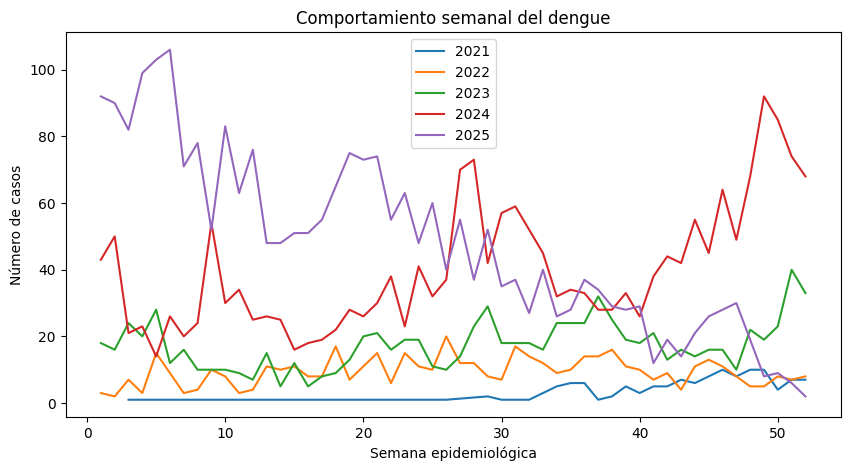

In [70]:
# Graficar comportamiento semanal del dengue por año
plt.figure(figsize=(10,5))

for año in casos_semana['año'].unique():

    subset = casos_semana[casos_semana['año'] == año]

    plt.plot(subset['semana'], subset['casos'], label=año)

plt.legend()

plt.xlabel("Semana epidemiológica")
plt.ylabel("Número de casos")

plt.title("Comportamiento semanal del dengue")

plt.show()

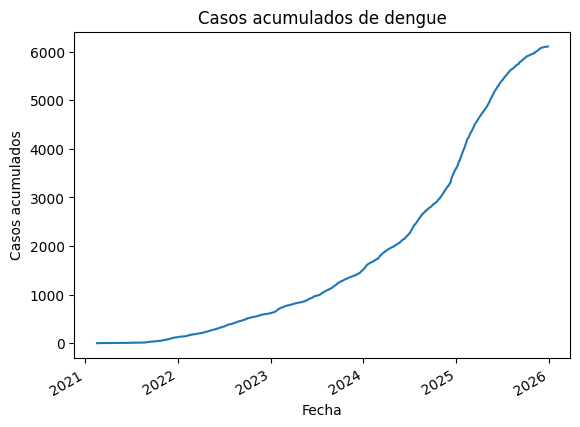

In [71]:
# Casos acumulados por fecha de notificación
casos_fecha = df.groupby('fec_not').size()

casos_acumulados = casos_fecha.cumsum()

plt.figure()

casos_acumulados.plot()

plt.title("Casos acumulados de dengue")

plt.xlabel("Fecha")

plt.ylabel("Casos acumulados")

plt.show()

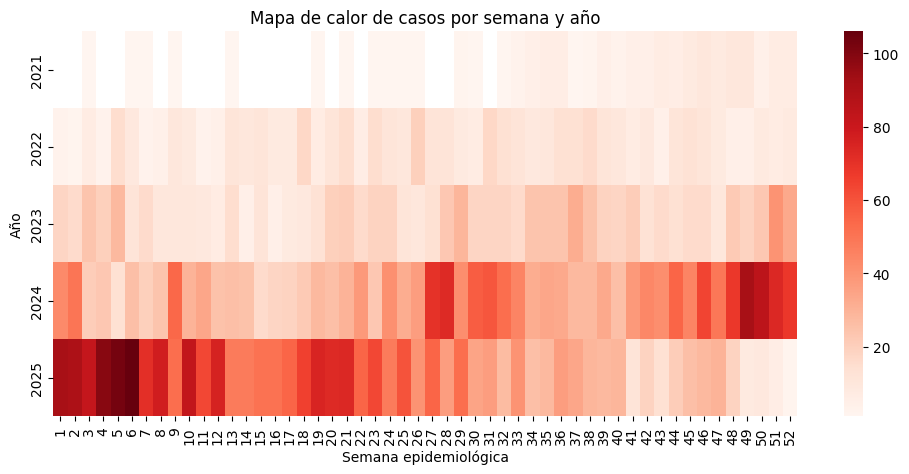

In [72]:
# Heatmap de semanas por año
tabla = df.groupby(['año','semana']).size().unstack()

plt.figure(figsize=(12,5))

sns.heatmap(tabla, cmap="Reds")

plt.title("Mapa de calor de casos por semana y año")

plt.xlabel("Semana epidemiológica")

plt.ylabel("Año")

plt.show()

# Datos fusionados

In [73]:
df_final=pd.read_excel(r"C:\Users\usuario1\Documents\GitHub\arima\1_programa_trabajo\2_ejecucion_plan_trabajo\2_consolidacion_datos_meteoro_epidemiologicos_reales\03_fusionados_y_limpieza_datos\datos_fusionados_semanales.xlsx")
df_final.head()
# Ver las ultimas filas para confirmar que se cargó correctamente
df_final.tail()

,fecha,año,semana_epidemiologica,casos_dengue,temp,temp_max,temp_min,hum_esp,hum_rel,prec,dias_lluvia,vel_vi,vel_vi_max,vel_vi_min,uv
257,2025-12-06,2025,49,8,25.527143,28.834286,23.198571,18.515714,90.502857,27.49,6,0.158571,0.392857,0.027143,2.065714
258,2025-12-13,2025,50,6,26.082857,29.091429,23.785714,19.244286,90.718571,20.94,4,0.164286,0.411429,0.034286,2.024286
259,2025-12-20,2025,51,7,26.020000,29.442857,23.658571,18.935714,89.791429,30.61,6,0.168571,0.447143,0.034286,2.067143
260,2025-12-27,2025,52,0,25.988571,30.090000,23.008571,17.994286,85.884286,2.51,1,0.185714,0.452857,0.018571,1.995714
261,2026-01-03,2026,1,0,26.170000,29.715000,23.545000,18.880000,88.850000,2.19,0,0.135000,0.317500,0.022500,-248.362500


# Prueba de normalidad

In [74]:
from scipy.stats import shapiro

# Seleccionar solo las columnas numéricas
numericas = df_final.select_dtypes(include=["float64", "int64"]) # esto elimina la fecha de lso atributos a determinar correlacion

# Aplicar Shapiro-Wilk a cada variable
resultados_normalidad = {}
for col in numericas.columns:
    stat, p = shapiro(numericas[col].dropna())
    resultados_normalidad[col] = {"Estadístico W": stat, "Valor p": p}

# Mostrar resultados
df_normalidad = pd.DataFrame(resultados_normalidad).T
df_normalidad["Normal (p>0.05)"] = df_normalidad["Valor p"] > 0.05
df_normalidad

,Estadístico W,Valor p,Normal (p>0.05)
año,0.901330,4.461115e-12,False
semana_epidemiologica,0.953964,2.266217e-07,False
casos_dengue,0.845805,1.860547e-15,False
temp,0.919058,1.001771e-10,False
temp_max,0.884930,3.448327e-13,False
temp_min,0.982600,2.750319e-03,False
hum_esp,0.949263,6.752439e-08,False
hum_rel,0.833027,4.151767e-16,False
prec,0.890131,7.548008e-13,False
dias_lluvia,0.884932,3.449065e-13,False


In [75]:
# Seleccionar solo las columnas numéricas
df_numerico = df_final.select_dtypes(include=['float64', 'int64']) # esto elimina la fecha de lso atributos a determinar correlacion

# Calcular la matriz de correlación de Spearman
corr_spearman = df_numerico.corr(method='spearman')

# Mostrar matriz en consola
print("Matriz de correlación de Spearman:\n")
corr_spearman

Matriz de correlación de Spearman:



,año,semana_epidemiologica,casos_dengue,temp,temp_max,temp_min,hum_esp,hum_rel,prec,dias_lluvia,vel_vi,vel_vi_max,vel_vi_min,uv
año,1.000000,-0.018825,0.818471,-0.298566,-0.323063,-0.095656,0.478902,0.414249,0.300964,0.317274,0.342517,0.369052,-0.197162,-0.248484
semana_epidemiologica,-0.018825,1.000000,0.036894,-0.486455,-0.515360,-0.168935,0.382654,0.472682,0.208141,0.219681,0.385734,0.347941,-0.144356,-0.044969
casos_dengue,0.818471,0.036894,1.000000,-0.279559,-0.330041,-0.030324,0.550828,0.451603,0.330702,0.367667,0.334358,0.370263,-0.173350,-0.209447
temp,-0.298566,-0.486455,-0.279559,1.000000,0.946138,0.706598,-0.430262,-0.830328,-0.550447,-0.595599,-0.645656,-0.652805,0.258549,0.206654
temp_max,-0.323063,-0.515360,-0.330041,0.946138,1.000000,0.495438,-0.604854,-0.933891,-0.642098,-0.677339,-0.657041,-0.655307,0.255256,0.100195
temp_min,-0.095656,-0.168935,-0.030324,0.706598,0.495438,1.000000,0.159666,-0.323321,-0.169634,-0.211929,-0.335385,-0.356664,0.143403,0.338768
hum_esp,0.478902,0.382654,0.550828,-0.430262,-0.604854,0.159666,1.000000,0.773792,0.596888,0.590721,0.541612,0.578308,-0.334246,0.106290
hum_rel,0.414249,0.472682,0.451603,-0.830328,-0.933891,-0.323321,0.773792,1.000000,0.711697,0.738685,0.629923,0.645879,-0.305235,-0.041626
prec,0.300964,0.208141,0.330702,-0.550447,-0.642098,-0.169634,0.596888,0.711697,1.000000,0.814700,0.357264,0.325453,-0.054636,0.096050
dias_lluvia,0.317274,0.219681,0.367667,-0.595599,-0.677339,-0.211929,0.590721,0.738685,0.814700,1.000000,0.387411,0.360496,-0.079644,0.087527


In [76]:
# Mostrar correlación de cada variable con casos de dengue
print("\nCorrelación de Spearman con casos de dengue:\n")
corr_spearman['casos_dengue'].sort_values(ascending=True)


Correlación de Spearman con casos de dengue:



temp_max                -0.330041
temp                    -0.279559
uv                      -0.209447
vel_vi_min              -0.173350
temp_min                -0.030324
semana_epidemiologica    0.036894
prec                     0.330702
vel_vi                   0.334358
dias_lluvia              0.367667
vel_vi_max               0.370263
hum_rel                  0.451603
hum_esp                  0.550828
año                      0.818471
casos_dengue             1.000000
Name: casos_dengue, dtype: float64

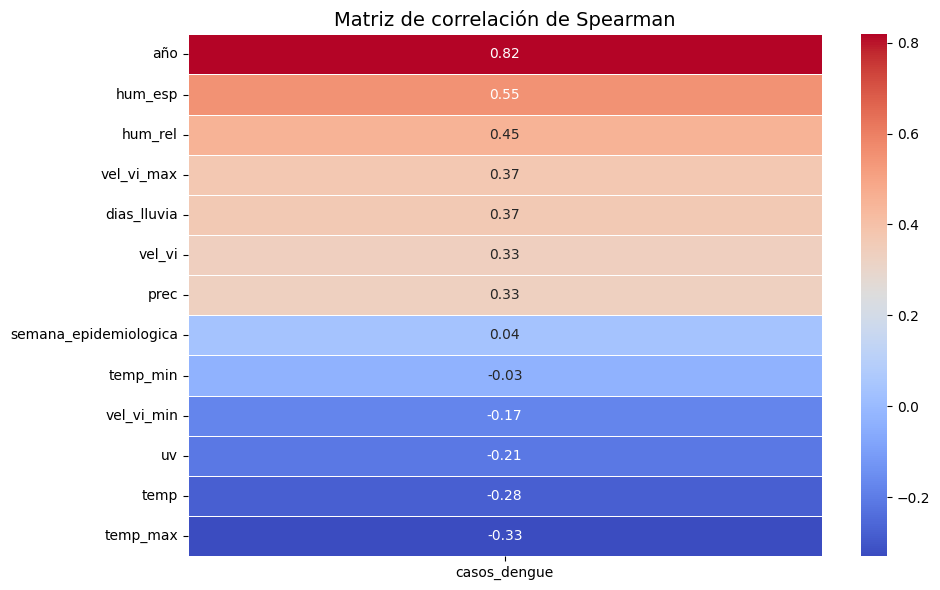

In [77]:
# Crear el mapa de calor
plt.figure(figsize=(10,6))
sns.heatmap(corr_spearman[['casos_dengue']].sort_values(by = 'casos_dengue' , ascending=False)[1:], 
    annot=True,       # Muestra los valores en el mapa
    cmap='coolwarm',  # Escala de color
    fmt=".2f",        # Formato de los valores
    linewidths=0.5
)
plt.title('Matriz de correlación de Spearman', fontsize=14)
plt.tight_layout()
plt.show()